<a href="https://colab.research.google.com/github/Shriansh16/ML_Revision/blob/main/KMEANS_REVISION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [2]:
X,y=make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
X

array([[-1.73561603,  0.11679857],
       [ 1.86139726,  7.90795128],
       [-8.68175323,  8.25996599],
       ...,
       [-0.6133151 ,  7.12328371],
       [-1.63871314, -0.35697156],
       [-0.71995016,  6.33968382]])

In [4]:
y

array([2, 1, 0, 0, 2, 1, 2, 1, 1, 2, 1, 2, 0, 1, 1, 1, 0, 0, 1, 1, 0, 2,
       2, 0, 2, 1, 1, 0, 0, 1, 0, 0, 0, 2, 0, 1, 1, 2, 2, 1, 1, 0, 1, 1,
       2, 1, 2, 2, 2, 1, 1, 2, 2, 2, 2, 2, 0, 1, 2, 0, 1, 0, 2, 0, 2, 0,
       0, 2, 2, 2, 1, 0, 1, 2, 1, 2, 2, 1, 2, 2, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 2, 2, 1, 2, 2, 0, 0, 1, 0, 1, 1, 1, 2, 0, 2, 0, 2, 1, 0, 0,
       1, 0, 1, 2, 2, 2, 2, 2, 0, 2, 0, 1, 1, 1, 0, 1, 2, 0, 2, 1, 0, 0,
       2, 0, 1, 2, 2, 1, 1, 2, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 2, 2, 0,
       0, 1, 0, 1, 1, 0, 2, 2, 2, 0, 1, 2, 2, 1, 0, 2, 2, 1, 2, 0, 1, 2,
       2, 1, 2, 0, 2, 2, 2, 2, 2, 1, 2, 1, 1, 0, 2, 2, 0, 2, 0, 2, 2, 0,
       0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 0, 1, 1, 2, 2, 1, 1, 1, 1,
       1, 2, 1, 0, 1, 1, 2, 0, 1, 0, 0, 0, 1, 2, 0, 1, 2, 1, 0, 2, 1, 1,
       0, 2, 0, 0, 2, 1, 2, 2, 0, 0, 0, 2, 0, 2, 1, 1, 2, 1, 1, 0, 0, 2,
       1, 1, 0, 2, 0, 2, 0, 1, 0, 1, 2, 0, 0, 2, 1, 1, 1, 0, 1, 0, 1, 2,
       0, 1, 2, 2, 1, 2, 2, 2, 0, 0, 2, 0, 0, 1, 2,

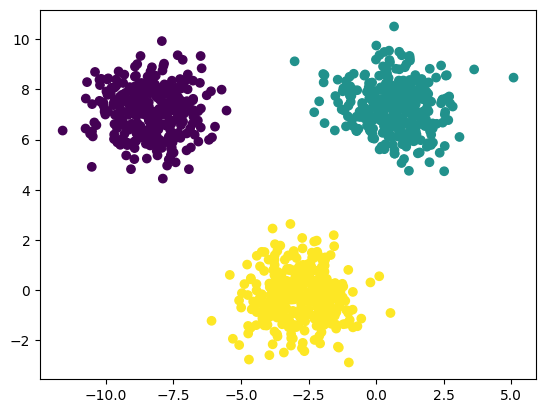

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [9]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

fit_transform on Training Data:
fit_transform(X_train): This method first computes the necessary statistics (like mean and variance for scaling) from the training data and then applies the transformation (scaling the data).
The scaler "learns" from the training data how it should scale data (what mean and standard deviation to use, for example).
transform on Test Data:
transform(X_test): This method only applies the previously learned transformation (from the training data) to the test data. It does not recompute the scaling parameters.
Why Not Use fit_transform on Test Data?
Data Leakage: If you use fit_transform on the test data, the scaler will compute the scaling parameters based on the test data. This introduces information from the test set into the model, which should ideally remain unseen during the training process. This is known as "data leakage" and can lead to overly optimistic model performance metrics, as the test data is no longer truly "unseen."
Consistency: By using transform, you ensure that the test data is scaled in the same way as the training data, maintaining consistency between training and testing phases.

In [10]:
from sklearn.cluster import KMeans

In [13]:
##elbow method to select k value
wcss=[]
for k in range(1,11):
  kmeans=KMeans(n_clusters=k,init='k-means++')
  kmeans.fit(X_train_scaled)
  wcss.append(kmeans.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

[]

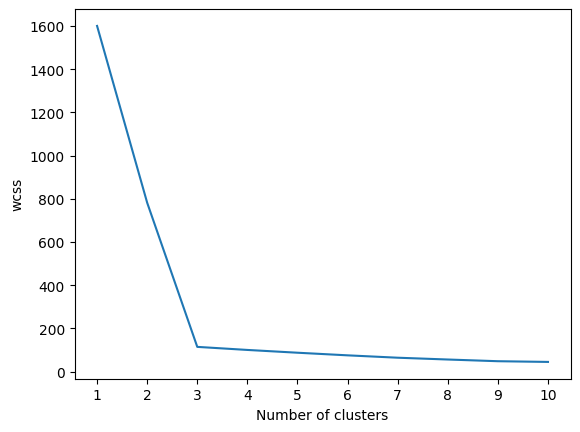

In [14]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of clusters")
plt.ylabel("wcss")
plt.plot()

In [15]:
## so, take k=3

In [17]:
kmeans=KMeans(n_clusters=3,init='k-means++')

kmeans.fit(X_train_scaled)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=3)

In [18]:
y_pred=kmeans.predict(X_test_scaled)

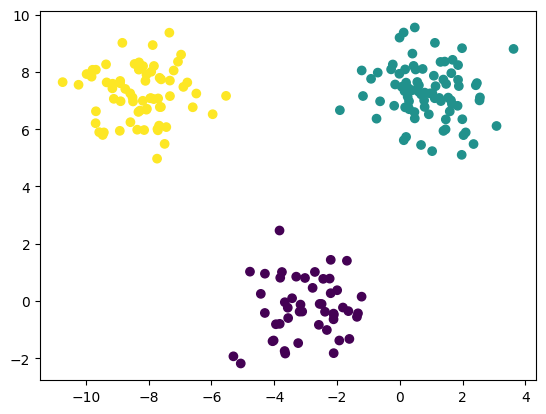

In [20]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [22]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [23]:
## kneelocator
!pip install kneed

In [24]:
from kneed import KneeLocator

In [25]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [26]:
kl.elbow

3

In [27]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [29]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

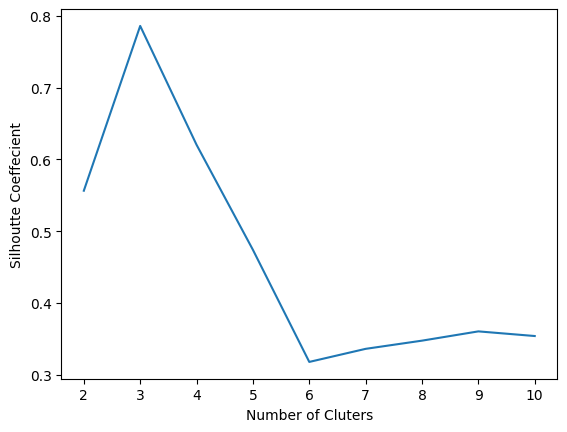

In [30]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()